# Using Intergrated Gradients and Grad-CAM to Explain CNNs

The trained cats-vs-dogs CNN's predictions from the previous small-datasets job are explained in this notebook. The model is neither modified nor retrained.

It is applicable for pixel attribution use Integrated Gradients.

For coarse class-discriminative localization, use Grad-CAM

The notebook automatically overlays both maps on the initial inputs, explains model's predicted class and chooses three succesfully categorized test photos and one misclassified image.

Upload the saved "cats_and_dogs_small_pth" when prompted.

In [ ]:
!pip -q install captum datasets

import base64, io
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from datasets import load_dataset
from captum.attr import IntegratedGradients, LayerGradCam, LayerAttribution

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 150
BATCH_SIZE = 32
CLASS_NAMES = ["cat", "dog"]

print("Device:", DEVICE)


## Preprocessing and the model

The four-block "SmallConvNet" is used in the cats-vs-dogs assignment is shown below. A convolution, ReLu and MaxPool procedure are preset in every block. For binary classification, the classifier uses dropout, hidden layer, and a single output logit.

The initial preprocessing normalizes each RGB with a mean of 0.5 and a standard deviation of 0.5 and resizes photos to 150 by 150 pixels.

In [ ]:
from google.colab import files
import io

print("Upload your cats_and_dogs_small.pth file.")
uploaded = files.upload()

if "cats_and_dogs_small.pth" not in uploaded:
    raise FileNotFoundError(
        "Please upload the file named cats_and_dogs_small.pth"
    )

class SmallConvNet(nn.Module):
    def __init__(self, dropout=True):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 128, 3), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5) if dropout else nn.Identity(),
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x).squeeze(1)

state = torch.load(
    io.BytesIO(uploaded["cats_and_dogs_small.pth"]),
    map_location=DEVICE
)

model = SmallConvNet(dropout=True).to(DEVICE)
model.load_state_dict(state)
model.eval()

print("Trained model loaded successfully.")


Upload your cats_and_dogs_small.pth file.


Saving cats_and_dogs_small.pth to cats_and_dogs_small.pth
Trained model loaded successfully.


In [ ]:
ds = load_dataset("pantelism/cats-vs-dogs")

basic_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

class CatsDogsDataset(Dataset):
    def __init__(self, split, transform):
        self.data = split
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        image = sample["image"].convert("RGB")
        return self.transform(image), int(sample["label"]), idx

test_ds = CatsDogsDataset(ds["test"], basic_tf)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Test images:", len(test_ds))


README.md:   0%|          | 0.00/602 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 45.7MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.3MB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Test images: 1000


In [ ]:
def predict(x):
    with torch.no_grad():
        logit = model(x.to(DEVICE))
        p_dog = torch.sigmoid(logit)
        pred = (p_dog >= 0.5).long()
    return pred, p_dog

correct, wrong = [], []

for images, labels, indices in test_loader:
    preds, probs = predict(images)
    for j in range(len(images)):
        ex = {
            "image": images[j:j+1].cpu(),
            "true": int(labels[j]),
            "pred": int(preds[j].cpu()),
            "p_dog": float(probs[j].cpu()),
            "index": int(indices[j]),
        }
        if ex["pred"] == ex["true"] and len(correct) < 3:
            correct.append(ex)
        elif ex["pred"] != ex["true"] and len(wrong) < 1:
            wrong.append(ex)

    if len(correct) == 3 and len(wrong) == 1:
        break

examples = correct + wrong

assert len(examples) == 4, "Could not find 3 correct and 1 incorrect example."

for i, ex in enumerate(examples, 1):
    status = "CORRECT" if ex["pred"] == ex["true"] else "MISCLASSIFIED"
    confidence = ex["p_dog"] if ex["pred"] == 1 else 1 - ex["p_dog"]
    print(
        f"Example {i}: test index {ex['index']} | "
        f"true={CLASS_NAMES[ex['true']]} | "
        f"predicted={CLASS_NAMES[ex['pred']]} | "
        f"confidence={confidence:.1%} | {status}"
    )


Example 1: test index 0 | true=cat | predicted=cat | confidence=91.3% | CORRECT
Example 2: test index 2 | true=cat | predicted=cat | confidence=70.8% | CORRECT
Example 3: test index 3 | true=cat | predicted=cat | confidence=73.9% | CORRECT
Example 4: test index 1 | true=cat | predicted=dog | confidence=84.4% | MISCLASSIFIED


# Integrated Gradients

### Intuition

By tracking how the chosen class score varies as the input shifts from a reference image to the actual image, Integrated Gradients provides an explanation for a prediction. It begins at a baseline, travels in a straight line from that baseline to the input, and assesses the gradient of the class score in relation to the pixes at numerous locations along the way. The difference between the input and baseline is used to scale and average those gradients.

Because a network may have saturated activations, this is better than simply examining the regular input gradient.Even if feature played a significant role in generating the prediction, a gradient at the final input can be near zero.Integrated Gradients gathers data all the way form baseline to input. Additionally, it possesses the completeness property: in the ideal integral, the attributions add up to the difference between the model output at the baseline and the model output at the real output.


### The baseline's function

I refer to a "all black image" raw black(0) correlates to -1 in normalized model input space because CNN expects images to be normalized from [0,1] to [-1, 1]. torch.full_like(x,-1,0) is the baseline.

The baseline is important since Intergrated Gradients provides a response to a relative question " which input characteristics explain the shift in the class score from this reference image?" Therefore, the attribution may be altered by a different baseline.

### Limitation

Baseline sensitvity is a drawback. Although a black image is practical, not all models will find it to be an entirely unbaised reference. Because attribution is given at the pixel level, Intergrated Gradients may also be visually noisy.

### Predicted-class score

There is just one output logit for the trained model dog is supported by positive logits, while cat is supported by negative logits. The wrapper below exposes two scores in order to make both classes explicit for Captum.

- cat score = -logit
  Dog score = +logit

  "target = predicted_class" is used for each example. Therefore, a rather than explaining a fixed class or the ground truth label, the gradients describe what motivated the model's actual prediction.


In [ ]:
class TwoClassWrapper(nn.Module):
    def __init__(self, base):
        super().__init__()
        self.base = base

    def forward(self, x):
        z = self.base(x)
        return torch.stack((-z, z), dim=1)

explain_model = TwoClassWrapper(model).to(DEVICE).eval()

ig = IntegratedGradients(explain_model)

def ig_map(image, predicted_class):
    x = image.to(DEVICE).clone().detach().requires_grad_(True)
    baseline = torch.full_like(x, -1.0)  # black after normalization

    attr, delta = ig.attribute(
        x,
        baselines=baseline,
        target=predicted_class,
        n_steps=100,
        return_convergence_delta=True,
    )

    heat = attr.abs().sum(dim=1)[0].detach().cpu().numpy()
    heat -= heat.min()
    if heat.max() > 0:
        heat /= heat.max()
    return heat, float(delta.detach().cpu().reshape(-1)[0])


# Grad-CAM

### Intuition

Grad-CAM uses a convolutional layer's spatial feature maps to explain a class prediction. It uses the gradients to determine the relative importance of each feature map for the class after reverse movement the chosen class score to that layer. A class discriminative heatmap is created by combining the weighted feature maps and running them through a ReLU.

### Role of the target layer

I aim for the fourth "Conv2d" layer, which is the last convolutional layer "model.features[9]". This is a good middle ground since it maintains a two dimensional spatial layout while including higher-level learnt properties than the early convolutions. The spatial organization would be absent from a fully connected layer.

### Limitation

Grad-CAM had a coarse spatial resolution. Because its heatmap is created at a deep feature map resolution and then extended to 150 x 150 pixels, it is more useful for locating a big area than for pinpointing precise decisive pixles.

In [ ]:
target_layer = model.features[9]
gradcam = LayerGradCam(explain_model, target_layer)

def gradcam_map(image, predicted_class):
    x = image.to(DEVICE).clone().detach().requires_grad_(True)

    attr = gradcam.attribute(x, target=predicted_class)
    attr = LayerAttribution.interpolate(
        attr,
        interpolate_dims=(IMG_SIZE, IMG_SIZE),
        interpolate_mode="bilinear",
    )

    heat = torch.relu(attr)
    heat = heat.mean(dim=1)[0] if heat.shape[1] > 1 else heat[0, 0]
    heat = heat.detach().cpu().numpy()
    heat -= heat.min()
    if heat.max() > 0:
        heat /= heat.max()
    return heat


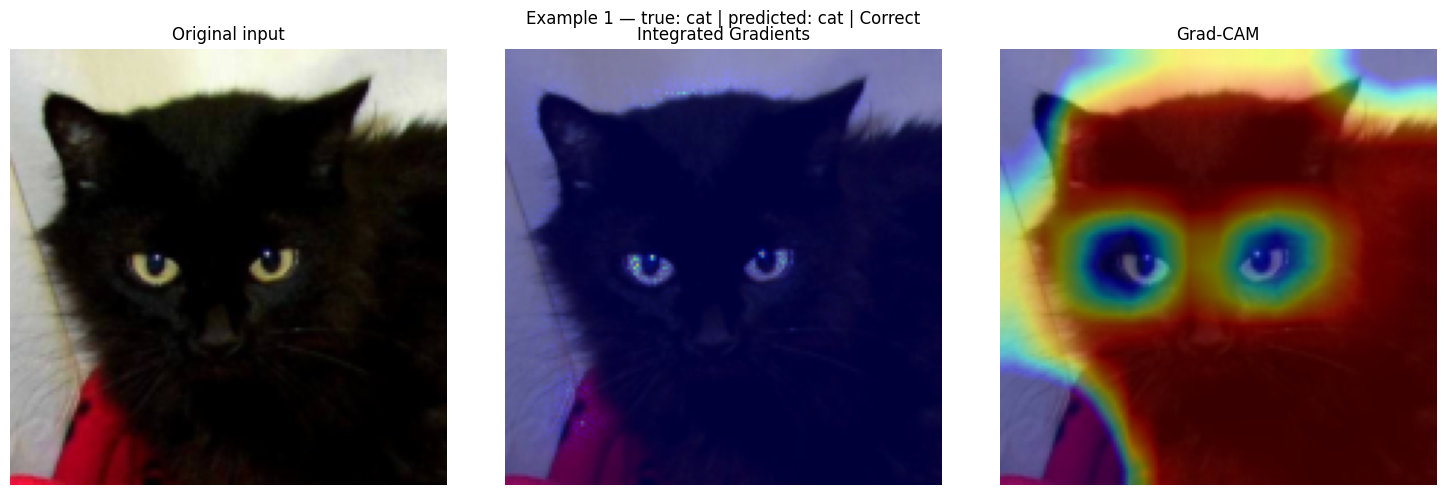

Caption: IG places its strongest fine-grained evidence around the middle-left of the image, while Grad-CAM's broader class-discriminative region is centered around the middle-center.
IG convergence delta: 0.000020



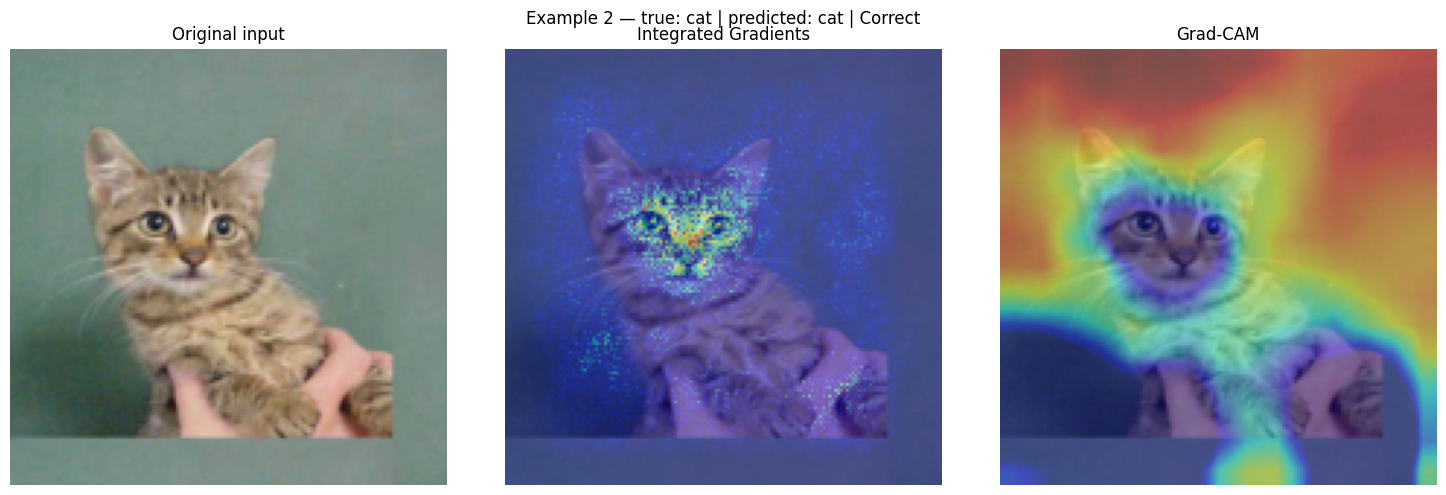

Caption: IG places its strongest fine-grained evidence around the middle-center of the image, while Grad-CAM's broader class-discriminative region is centered around the upper-center.
IG convergence delta: 0.006989



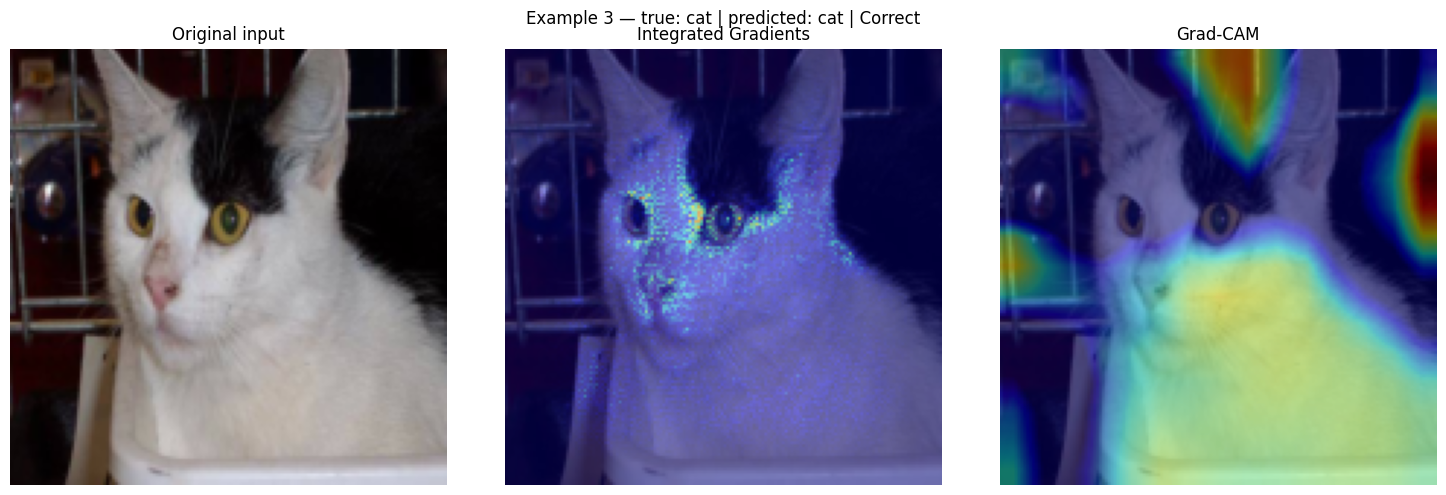

Caption: IG places its strongest fine-grained evidence around the middle-center of the image, while Grad-CAM's broader class-discriminative region is centered around the lower-center.
IG convergence delta: -0.000615



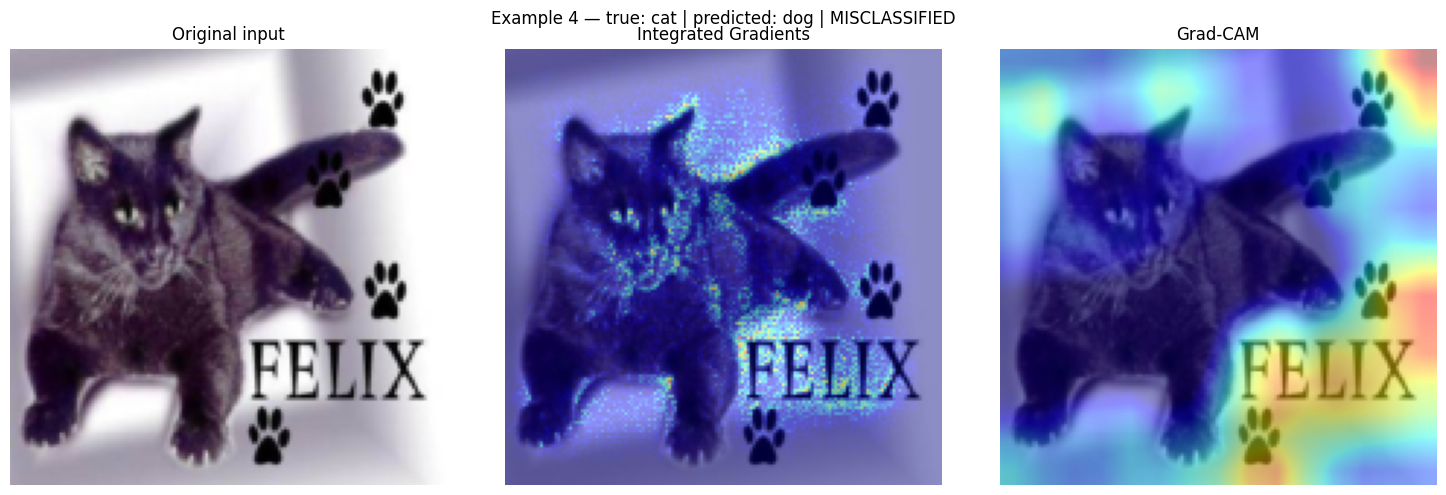

Caption: IG places its strongest fine-grained evidence around the middle-center of the image, while Grad-CAM's broader class-discriminative region is centered around the middle-right.
IG convergence delta: 0.005057



In [ ]:
def denormalize(x):
    image = x[0].permute(1, 2, 0).numpy()
    return np.clip(image * 0.5 + 0.5, 0, 1)

def center_description(heat):
    h, w = heat.shape
    yy, xx = np.mgrid[0:h, 0:w]
    weights = heat + 1e-8
    cx = (xx * weights).sum() / weights.sum() / w
    cy = (yy * weights).sum() / weights.sum() / h

    horizontal = "left" if cx < .4 else "right" if cx > .6 else "center"
    vertical = "upper" if cy < .4 else "lower" if cy > .6 else "middle"
    return f"{vertical}-{horizontal}"

all_maps = []

for i, ex in enumerate(examples, 1):
    rgb = denormalize(ex["image"])
    ig_heat, delta = ig_map(ex["image"], ex["pred"])
    cam_heat = gradcam_map(ex["image"], ex["pred"])
    all_maps.append((ig_heat, cam_heat))

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    ax[0].imshow(rgb)
    ax[0].axis("off")
    ax[0].set_title("Original input")

    ax[1].imshow(rgb)
    ax[1].imshow(ig_heat, cmap="jet", alpha=.45)
    ax[1].axis("off")
    ax[1].set_title("Integrated Gradients")

    ax[2].imshow(rgb)
    ax[2].imshow(cam_heat, cmap="jet", alpha=.45)
    ax[2].axis("off")
    ax[2].set_title("Grad-CAM")

    status = "Correct" if ex["pred"] == ex["true"] else "MISCLASSIFIED"
    fig.suptitle(
        f"Example {i} — true: {CLASS_NAMES[ex['true']]} | "
        f"predicted: {CLASS_NAMES[ex['pred']]} | {status}"
    )
    plt.tight_layout()
    plt.show()

    print(
        f"Caption: IG places its strongest fine-grained evidence around the "
        f"{center_description(ig_heat)} of the image, while Grad-CAM's broader "
        f"class-discriminative region is centered around the "
        f"{center_description(cam_heat)}."
    )
    print(f"IG convergence delta: {delta:.6f}\n")


## Visual reading and captions

The necessary overlay visualization is satisfied by the above figures. The location of the strongest attribution is reproducibly described in the printed one line caption. I also look at the visible image content beneath those sections when reading the plots; strong attribution on the animal is more comforting than strong attribution on the background, borders, text, furniture, or any other incidental clue.


In [ ]:
def top_mask(heat, fraction=.20):
    return heat >= np.quantile(heat, 1 - fraction)

def jaccard(a, b):
    intersection = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return intersection / union if union else 0.0

overlaps = []

for i, ((ig_heat, cam_heat), ex) in enumerate(zip(all_maps, examples), 1):
    overlap = jaccard(top_mask(ig_heat), top_mask(cam_heat))
    overlaps.append(overlap)
    status = "correct" if ex["pred"] == ex["true"] else "misclassified"
    print(f"Example {i} ({status}): top-20% IG/Grad-CAM overlap = {overlap:.3f}")

print("\nMean overlap:", np.mean(overlaps))


Example 1 (correct): top-20% IG/Grad-CAM overlap = 0.001
Example 2 (correct): top-20% IG/Grad-CAM overlap = 0.022
Example 3 (correct): top-20% IG/Grad-CAM overlap = 0.111
Example 4 (misclassified): top-20% IG/Grad-CAM overlap = 0.143

Mean overlap: 0.06916092753260587


# Comparison and interpretation

Different but complimentary perspectives on CNN's prediction process are offered by Intergrated Gradients and Grad-CAM. Integrated Gradients tend to emphasize edges, textures, and minor visual elements while providing a thorough, pixel-level explanation. Because Grad-CAM incorporates the feature maps from the final convolutional layer it, generates a more comprehensive heatmap. Combining the two approaches makes it simpler to determine which aspects of an image affected the model.

### Where they agree

Both approaches demonstrate that characteristics related to the animals influenced the predictions in the correctly identified samples. Nevertheless, there is little overlap between their strongest emphasized areas. With an average of roughly 0.069, the top 20% overlap values between Intergrated Gradients and Grad-CAM were 0.001, 0.022, 0.111, and 0.143.

Given that the two approaches function at different resolutions, the comparatively limited overlap is not particularly suprising. Grad-CAM uses the CNN's deeper feature maps to identify larger regions, whereas Intergrated Gradients pinpoints individual pixles that influence the prediction. Both can show that the model is utilizing data form the animal, even if their heatmaps appear different.

### Where they disagree

The degree of depth in their explanations is the primary distinction between the approaches. Grad-CAM generates smoother and broader highlighted regions, whereas Intergrated Gradients generates more dispersed and accurate attribution around individual features. In certain instances, Grad-CAM also encompasses the animal's surroundings, whereas Intergrated Gradients focuses more an particular characteristics.

This disagreement is helpful since it demonstrates that a saliency map is not an ideal representation of the model's logic. The same forecast can have different characteristics highlighted by different explaining techniques.

### What the misclassified example reveals

The fourth case is very intriguing since the model predicts dog with 84.4% confidence despite the image showing a cat Intergrated Gradients draws attention to certain sections of the cat, such as those surrounding its face and body, while also emphasizing other areas of picture. Grad-CAM draws attention to the "FELIX" text, paw-print images, and background on the right side of the image while highlighting a larger area.

This imploes that the model might not base its conclusion just on the animal. The prediction may also be influenced by other visual patterns and background information. The incorrect dog classification may have been influenced by these contextual factors.

Interestingly, at 0.143, the misclassified case exhibits the most top 20% overlap between Grad-CAM and Integrated Gradients.This demonstrates that a forecast is not always accurate just because two explanatory approaches agree. Even if the evidence results in an incorrect categorization, both appraoches can agree on which evidence affected the network.




## References

Sundararajan, M., Taly, A., & Yan, Q. (2017). **Axiomatic Attribution for Deep Networks.** ICML. arXiv:1703.01365.

Selvaraju, R. R., et al. (2017). **Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization.** ICCV. arXiv:1610.02391.

PyTorch/Captum: **Model Understanding with Captum**.


Dataset: **pantelism/cats-vs-dogs**, Hugging Face.
